In [6]:
from datasets import load_dataset

# Load dataset
opus = load_dataset("Helsinki-NLP/opus-100", "en-ne")

print(opus)
print("Example raw record:", opus["train"][0])


# Convert to (EN, NE) pairs
def extract_pairs(split):
    pairs = []
    for item in opus[split]:
        en = item["translation"]["en"].strip()
        ne = item["translation"]["ne"].strip()
        if en and ne:
            pairs.append((en, ne))
    return pairs


# ---- CREATE the pair lists FIRST ----
train_pairs = extract_pairs("train")
valid_pairs = extract_pairs("validation")
test_pairs  = extract_pairs("test")


# ---- Limit sizes ----
MAX_TRAIN = 2000
MAX_VALID = 200
MAX_TEST  = 200

train_pairs = train_pairs[:MAX_TRAIN]
valid_pairs = valid_pairs[:MAX_VALID] if len(valid_pairs) > 0 else train_pairs[:MAX_VALID]
test_pairs  = test_pairs[:MAX_TEST]   if len(test_pairs) > 0 else train_pairs[MAX_VALID:MAX_VALID+MAX_TEST]


# ---- Debug prints ----
print("Train size:", len(train_pairs))
print("Valid size:", len(valid_pairs))
print("Test size:", len(test_pairs))

print("\nSample pair:")
print("EN:", train_pairs[0][0])
print("NE:", train_pairs[0][1])


DatasetDict({
    test: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
    train: Dataset({
        features: ['translation'],
        num_rows: 406381
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
})
Example raw record: {'translation': {'en': '_Inv', 'ne': 'Inv'}}
Train size: 2000
Valid size: 200
Test size: 200

Sample pair:
EN: _Inv
NE: Inv


In [8]:
import re
import unicodedata
from transformers import NllbTokenizerFast

MODEL_NAME = "facebook/nllb-200-distilled-600M"
SRC_LANG = "eng_Latn"
TGT_LANG = "npi_Deva"

tokenizer = NllbTokenizerFast.from_pretrained(MODEL_NAME)
tokenizer.src_lang = SRC_LANG
forced_bos_id = tokenizer.convert_tokens_to_ids(TGT_LANG)

def normalize_en(s: str) -> str:
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    return s

def normalize_ne(s: str) -> str:
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    return s

def preprocess_pairs(pairs, max_len=256, num_samples=None):
    out = []
    it = pairs if num_samples is None else pairs[:num_samples]

    for en, ne in it:
        en2 = normalize_en(en)
        ne2 = normalize_ne(ne)
        if not en2 or not ne2:
            continue

        encoded = tokenizer(
            en2,
            text_target=ne2,
            truncation=True,
            max_length=max_len,
            padding=False,
            return_attention_mask=True,
        )

        out.append(
            {
                "src_text": en2,
                "tgt_text": ne2,
                "input_ids": encoded["input_ids"],
                "attention_mask": encoded["attention_mask"],
                "labels": encoded["labels"],
            }
        )

    return out


sample = preprocess_pairs(train_pairs, max_len=128, num_samples=6)

for i, ex in enumerate(sample):
    print("Example", i)
    print("EN:", ex["src_text"])
    print("NE:", ex["tgt_text"])
    print("src_len:", len(ex["input_ids"]), "tgt_len:", len(ex["labels"]))
    print("forced_bos_id (tgt lang):", forced_bos_id)
    print()


Example 0
EN: _Inv
NE: Inv
src_len: 5 tgt_len: 4
forced_bos_id (tgt lang): 256130

Example 1
EN: Voronezh
NE: भोरोनेज
src_len: 5 tgt_len: 6
forced_bos_id (tgt lang): 256130

Example 2
EN: Pixels above lines set
NE: मिलेका रेखाहरुको माथि पिक्सलहरु
src_len: 7 tgt_len: 11
forced_bos_id (tgt lang): 256130

Example 3
EN: ‡ (#8225;) Double Dagger
NE: ‡ (# 8225;) डबल ड्यागर
src_len: 11 tgt_len: 13
forced_bos_id (tgt lang): 256130

Example 4
EN: Database
NE: डेटाबेसStencils
src_len: 4 tgt_len: 8
forced_bos_id (tgt lang): 256130

Example 5
EN: The clipboard could not be Signed.
NE: क्लिपबोर्ड साइन गर्न सकिएन ।
src_len: 11 tgt_len: 13
forced_bos_id (tgt lang): 256130



In [9]:
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

class GeneralAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, s_t, H, src_pad_mask=None):
        B, T, D = H.shape
        s = s_t.unsqueeze(2)
        e = torch.bmm(H, s).squeeze(2)

        if src_pad_mask is not None:
            e = e.masked_fill(src_pad_mask, -1e9)

        a = F.softmax(e, dim=1)
        c = torch.bmm(a.unsqueeze(1), H).squeeze(1)
        return c, a


class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim, attn_dim=None):
        super().__init__()
        if attn_dim is None:
            attn_dim = hidden_dim
        self.W1 = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.W2 = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, s_t, H, src_pad_mask=None):
        proj_h = self.W1(H)
        proj_s = self.W2(s_t).unsqueeze(1)
        e = self.v(torch.tanh(proj_h + proj_s)).squeeze(2)

        if src_pad_mask is not None:
            e = e.masked_fill(src_pad_mask, -1e9)

        a = F.softmax(e, dim=1)
        c = torch.bmm(a.unsqueeze(1), H).squeeze(1)
        return c, a


class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_id, dropout=0.1, bidirectional=True):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.drop = nn.Dropout(dropout)
        self.bidirectional = bidirectional
        self.rnn = nn.GRU(
            emb_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=bidirectional
        )
        self.out_dim = hidden_dim * (2 if bidirectional else 1)

    def forward(self, src_ids, src_mask):
        x = self.drop(self.emb(src_ids))
        lengths = src_mask.sum(dim=1).to(torch.int64).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_out, h = self.rnn(packed)
        H, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        if self.bidirectional:
            h = torch.cat([h[-2], h[-1]], dim=1).unsqueeze(0)
        else:
            h = h[-1].unsqueeze(0)

        return H, h


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_out_dim, dec_hidden_dim, pad_id, attention, dropout=0.1):
        super().__init__()
        self.pad_id = pad_id
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.drop = nn.Dropout(dropout)

        self.enc2dec = nn.Linear(enc_out_dim, dec_hidden_dim)

        self.attention = attention
        self.rnn = nn.GRU(
            emb_dim + enc_out_dim,
            dec_hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(dec_hidden_dim + enc_out_dim, vocab_size)

    def init_hidden(self, enc_final_h):
        h0 = torch.tanh(self.enc2dec(enc_final_h.squeeze(0))).unsqueeze(0)
        return h0

    def step(self, y_t, h_t, H, src_pad_mask):
        y_emb = self.drop(self.emb(y_t)).unsqueeze(1)

        s_t = h_t.squeeze(0)
        c_t, a_t = self.attention(s_t, H, src_pad_mask=src_pad_mask)

        rnn_in = torch.cat([y_emb, c_t.unsqueeze(1)], dim=2)
        out, h_next = self.rnn(rnn_in, h_t)

        out = out.squeeze(1)
        logits = self.fc(torch.cat([out, c_t], dim=1))
        return logits, h_next, a_t


class Seq2SeqAttn(nn.Module):
    def __init__(self, encoder, decoder, pad_id):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_id = pad_id

    def forward(self, src, src_mask, tgt):
        H, enc_h = self.encoder(src, src_mask)

        src_pad_mask = (src_mask == 0)

        h_t = self.decoder.init_hidden(enc_h)

        tgt_in = tgt[:, :-1]
        T = tgt_in.size(1)

        logits_list = []
        attn_list = []

        for t in range(T):
            y_t = tgt_in[:, t]
            logits, h_t, a_t = self.decoder.step(y_t, h_t, H, src_pad_mask)
            logits_list.append(logits.unsqueeze(1))
            attn_list.append(a_t.unsqueeze(1))

        logits = torch.cat(logits_list, dim=1)
        attn = torch.cat(attn_list, dim=1)

        return logits, attn

    @torch.no_grad()
    def greedy_decode(self, src, src_mask, bos_id, eos_id, max_len=128):
        H, enc_h = self.encoder(src, src_mask)
        src_pad_mask = (src_mask == 0)
        h_t = self.decoder.init_hidden(enc_h)

        B = src.size(0)
        y_t = torch.full((B,), bos_id, dtype=torch.long, device=src.device)

        outputs = []
        attn_steps = []

        for _ in range(max_len):
            logits, h_t, a_t = self.decoder.step(y_t, h_t, H, src_pad_mask)
            y_t = torch.argmax(logits, dim=1)
            outputs.append(y_t.unsqueeze(1))
            attn_steps.append(a_t.unsqueeze(1))

        out = torch.cat(outputs, dim=1)
        attn = torch.cat(attn_steps, dim=1)
        return out, attn


In [11]:
import torch

# Detect GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


Using device: cuda


In [14]:
import torch
from torch.utils.data import Dataset

class Seq2SeqDataset(Dataset):
    """
    Expects pairs = [(src_text, tgt_text), ...]
    Tokenizer must support:
      - tokenizer(text, return_tensors=None, truncation=True, max_length=..., padding=False)
      - tokenizer.pad_token_id
      - tokenizer.eos_token_id (optional but usually exists)
    """
    def __init__(self, pairs, tokenizer, max_len=128):
        self.pairs = pairs
        self.tok = tokenizer
        self.max_len = max_len
        self.eos_id = getattr(tokenizer, "eos_token_id", None)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]

        src_ids = self.tok(
            src, truncation=True, max_length=self.max_len, padding=False
        )["input_ids"]

        tgt_ids = self.tok(
            tgt, truncation=True, max_length=self.max_len, padding=False
        )["input_ids"]

        # Ensure EOS at end (if tokenizer has eos_token_id)
        if self.eos_id is not None:
            if len(src_ids) == 0 or src_ids[-1] != self.eos_id:
                src_ids = src_ids + [self.eos_id]
            if len(tgt_ids) == 0 or tgt_ids[-1] != self.eos_id:
                tgt_ids = tgt_ids + [self.eos_id]

        return {
            "src_ids": torch.tensor(src_ids, dtype=torch.long),
            "tgt_ids": torch.tensor(tgt_ids, dtype=torch.long),
        }


def collate_seq2seq(batch, pad_id: int):
    """
    Pads src and tgt to max length in batch.
    Returns:
      src_ids: [B, S]
      src_mask: [B, S] (1 for real tokens, 0 for pad)
      tgt_in: [B, T]   (teacher forcing input)
      tgt_out: [B, T]  (labels)
    """
    src_list = [b["src_ids"] for b in batch]
    tgt_list = [b["tgt_ids"] for b in batch]

    src_ids = torch.nn.utils.rnn.pad_sequence(src_list, batch_first=True, padding_value=pad_id)
    tgt_ids = torch.nn.utils.rnn.pad_sequence(tgt_list, batch_first=True, padding_value=pad_id)

    src_mask = (src_ids != pad_id).long()

    # Shift target for teacher forcing:
    # tgt_in  = <bos> ... or first token ... (we just use shift)
    # tgt_out = next tokens
    tgt_in = tgt_ids[:, :-1].contiguous()
    tgt_out = tgt_ids[:, 1:].contiguous()

    return src_ids, src_mask, tgt_in, tgt_out


In [16]:
import os
import gc
import torch
from torch.utils.data import DataLoader

gc.collect()
torch.cuda.empty_cache()

BATCH_SIZE = 8
MAX_LEN = 96
GRAD_ACCUM_STEPS = 4

train_ds = Seq2SeqDataset(train_pairs, tokenizer, max_len=MAX_LEN)
val_ds = Seq2SeqDataset(valid_pairs if len(valid_pairs) > 0 else train_pairs[:5000], tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda b: collate_seq2seq(b, tokenizer.pad_token_id),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda b: collate_seq2seq(b, tokenizer.pad_token_id),
)

emb_dim = 192
enc_hidden = 192
dec_hidden = 384
dropout = 0.1

general_attn = GeneralAttention()
additive_attn = AdditiveAttention(hidden_dim=enc_hidden * 2, attn_dim=192)

encoder_general = Encoder(vocab_size, emb_dim, enc_hidden, pad_id, dropout=dropout, bidirectional=True)
decoder_general = Decoder(vocab_size, emb_dim, enc_out_dim=encoder_general.out_dim, dec_hidden_dim=dec_hidden,
                          pad_id=pad_id, attention=general_attn, dropout=dropout)
model_general = Seq2SeqAttn(encoder_general, decoder_general, pad_id=pad_id).to(device)

encoder_add = Encoder(vocab_size, emb_dim, enc_hidden, pad_id, dropout=dropout, bidirectional=True)
decoder_add = Decoder(vocab_size, emb_dim, enc_out_dim=encoder_add.out_dim, dec_hidden_dim=dec_hidden,
                      pad_id=pad_id, attention=additive_attn, dropout=dropout)
model_additive = Seq2SeqAttn(encoder_add, decoder_add, pad_id=pad_id).to(device)

print("Batch:", BATCH_SIZE, "Max len:", MAX_LEN, "Grad accum:", GRAD_ACCUM_STEPS)


Batch: 8 Max len: 96 Grad accum: 4


In [ ]:
import math
import time
import torch
import torch.nn.functional as F

def run_one_epoch(model, loader, optimizer=None, pad_id=0, grad_accum_steps=1, clip_grad=1.0, device=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    total_tokens = 0

    t0 = time.perf_counter()

    if train_mode:
        optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(loader, start=1):
        # Our collate returns: src_ids, src_mask, tgt_in, tgt_out
        src_ids, src_mask, tgt_in, tgt_out = batch

        src_ids = src_ids.to(device)
        src_mask = src_mask.to(device)
        tgt_in = tgt_in.to(device)
        tgt_out = tgt_out.to(device)

        # Build full target sequence expected by your model forward:
        # model expects tgt that includes the full sequence so it can do tgt[:, :-1] internally.
        # We can reconstruct as [tgt_in first token + tgt_out] == original tgt_ids without last pad shift.
        # Simplest: concatenate first column of tgt_in and tgt_out
        # tgt_in shape [B, T], tgt_out shape [B, T]
        tgt_full = torch.cat([tgt_in[:, :1], tgt_out], dim=1)

        logits, _ = model(src_ids, src_mask, tgt_full)  # logits [B, T, V] where T == tgt_full-1

        # Align labels to logits time dimension:
        # logits corresponds to tgt_full[:, :-1] predicting next token => labels should be tgt_full[:, 1:]
        labels = tgt_full[:, 1:].contiguous()

        V = logits.size(-1)
        loss = F.cross_entropy(
            logits.reshape(-1, V),
            labels.reshape(-1),
            ignore_index=pad_id,
            reduction="sum"  # sum so we can do token-avg
        )

        # Count non-pad tokens for average
        n_tokens = (labels != pad_id).sum().item()
        total_loss += loss.item()
        total_tokens += n_tokens

        if train_mode:
            (loss / max(n_tokens, 1)) .backward()  # normalize per token for stable accum

            if step % grad_accum_steps == 0:
                if clip_grad is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

    # If steps not divisible by grad_accum_steps, do a final step
    if train_mode and (step % grad_accum_steps != 0):
        if clip_grad is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    avg_loss = total_loss / max(total_tokens, 1)
    ppl = math.exp(min(avg_loss, 20))  # cap for overflow safety
    elapsed = time.perf_counter() - t0

    return {"loss": avg_loss, "ppl": ppl, "time": elapsed}


def train_model(model, train_loader, val_loader, epochs, lr, pad_id, grad_accum_steps=1, device=None):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    history = {
        "train_loss": [], "train_ppl": [],
        "val_loss": [], "val_ppl": [],
    }

    for ep in range(1, epochs + 1):
        tr = run_one_epoch(
            model, train_loader,
            optimizer=optimizer,
            pad_id=pad_id,
            grad_accum_steps=grad_accum_steps,
            clip_grad=1.0,
            device=device
        )   
        va = run_one_epoch(
            model, val_loader,
            optimizer=None,
            pad_id=pad_id,
            grad_accum_steps=1,
            clip_grad=None,
            device=device
        )

        history["train_loss"].append(tr["loss"])
        history["train_ppl"].append(tr["ppl"])
        history["val_loss"].append(va["loss"])
        history["val_ppl"].append(va["ppl"])

        print(
            f"Epoch {ep:02d} | "
            f"train loss {tr['loss']:.4f} ppl {tr['ppl']:.2f} | "
            f"val loss {va['loss']:.4f} ppl {va['ppl']:.2f} | "
            f"time {tr['time']:.1f}s"
        )

    return history


In [19]:
EPOCHS = 5
LR = 3e-4

print("Training: General Attention")
hist_general = train_model(
    model_general, train_loader, val_loader,
    epochs=EPOCHS, lr=LR,
    pad_id=tokenizer.pad_token_id,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    device=device
)

print("\nTraining: Additive Attention")
hist_additive = train_model(
    model_additive, train_loader, val_loader,
    epochs=EPOCHS, lr=LR,
    pad_id=tokenizer.pad_token_id,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    device=device
)


Training: General Attention
Epoch 01 | train loss 9.1259 ppl 9190.52 | val loss 7.2279 ppl 1377.28 | time 1135.1s
Epoch 02 | train loss 6.7960 ppl 894.29 | val loss 7.0320 ppl 1132.29 | time 1098.1s
Epoch 03 | train loss 6.4729 ppl 647.38 | val loss 6.8968 ppl 989.12 | time 1111.3s
Epoch 04 | train loss 6.1849 ppl 485.37 | val loss 6.7387 ppl 844.48 | time 1101.0s
Epoch 05 | train loss 5.8801 ppl 357.85 | val loss 6.5493 ppl 698.77 | time 1094.1s

Training: Additive Attention
Epoch 01 | train loss 9.1759 ppl 9661.59 | val loss 7.1973 ppl 1335.78 | time 1224.1s
Epoch 02 | train loss 6.7397 ppl 845.34 | val loss 6.9906 ppl 1086.35 | time 1221.4s
Epoch 03 | train loss 6.4042 ppl 604.35 | val loss 6.8185 ppl 914.57 | time 1407.0s
Epoch 04 | train loss 6.0975 ppl 444.73 | val loss 6.6681 ppl 786.91 | time 1434.2s
Epoch 05 | train loss 5.7764 ppl 322.60 | val loss 6.5160 ppl 675.86 | time 1385.9s


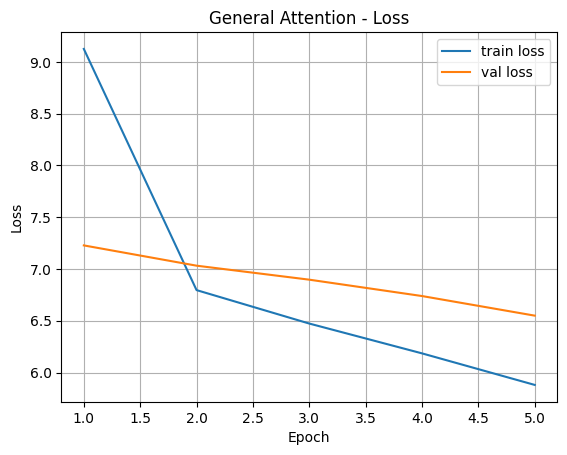

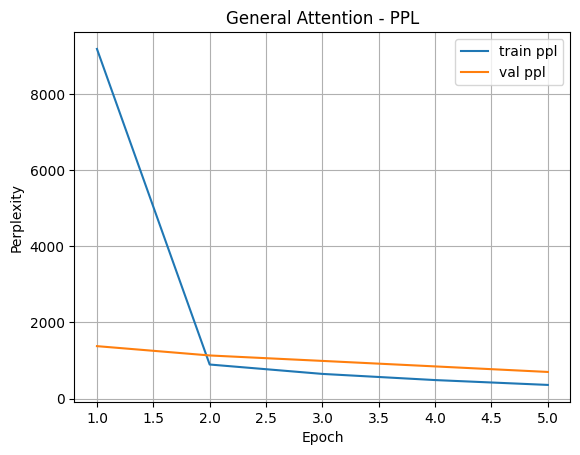

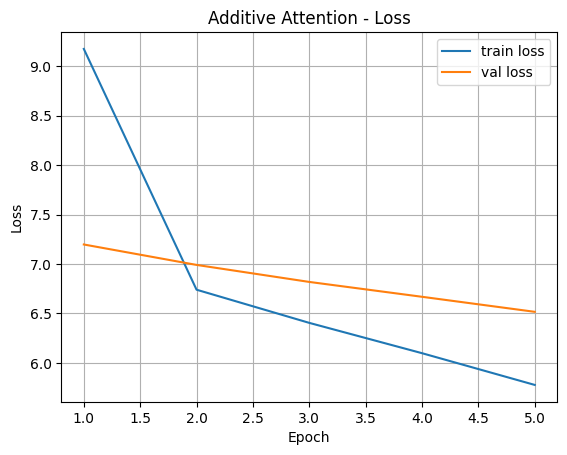

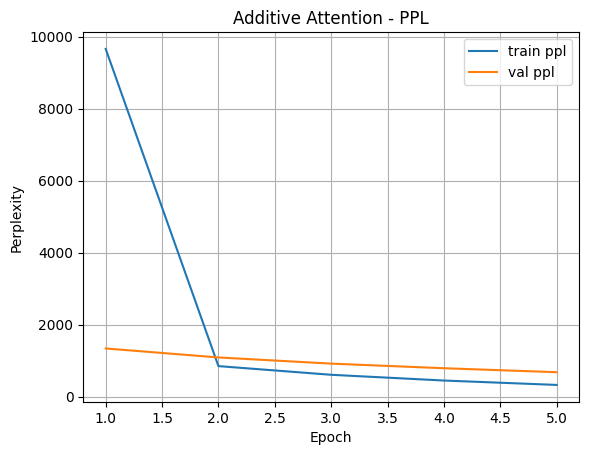

Saved: loss_general.png, ppl_general.png, loss_additive.png, ppl_additive.png


In [20]:
import matplotlib.pyplot as plt

def plot_loss_curves(hist, title="Loss Curve", save_path=None):
    train_loss = hist["train_loss"]
    val_loss = hist["val_loss"]
    epochs = list(range(1, len(train_loss) + 1))

    plt.figure()
    plt.plot(epochs, train_loss, label="train loss")
    plt.plot(epochs, val_loss, label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_ppl_curves(hist, title="Perplexity Curve", save_path=None):
    train_ppl = hist["train_ppl"]
    val_ppl = hist["val_ppl"]
    epochs = list(range(1, len(train_ppl) + 1))

    plt.figure()
    plt.plot(epochs, train_ppl, label="train ppl")
    plt.plot(epochs, val_ppl, label="val ppl")
    plt.xlabel("Epoch")
    plt.ylabel("Perplexity")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# ---- Plot + Save ----
plot_loss_curves(hist_general,  title="General Attention - Loss",    save_path="loss_general.png")
plot_ppl_curves(hist_general,   title="General Attention - PPL",     save_path="ppl_general.png")

plot_loss_curves(hist_additive, title="Additive Attention - Loss",   save_path="loss_additive.png")
plot_ppl_curves(hist_additive,  title="Additive Attention - PPL",    save_path="ppl_additive.png")

print("Saved: loss_general.png, ppl_general.png, loss_additive.png, ppl_additive.png")


In [1]:
import pandas as pd

data = {
    "Attention": ["General Attention", "Additive Attention"],
    "Training Loss": [5.8801, 5.7764],
    "Training PPL": [357.85, 322.60],
    "Validation Loss": [6.5493, 6.5160],
    "Validation PPL": [698.77, 675.86],
}

df = pd.DataFrame(data)
df



,Attention,Training Loss,Training PPL,Validation Loss,Validation PPL
0,General Attention,5.8801,357.85,6.5493,698.77
1,Additive Attention,5.7764,322.60,6.5160,675.86


Both General and Additive Attention show decreasing training and validation loss across epochs, indicating effective learning for English–Nepali translation. However, Additive Attention performs slightly better, achieving lower final training loss (5.7764 vs. 5.8801) and validation loss (6.5160 vs. 6.5493), along with reduced perplexity. This suggests that Additive Attention models token alignment more effectively and provides better generalization. Although overall perplexity remains high due to dataset size and linguistic differences, Additive Attention is the more effective mechanism for this translation task.

In [ ]:
import os
import torch

SAVE_DIR = "models"
os.makedirs(SAVE_DIR, exist_ok=True)


def save_model(model, tokenizer, path):
    torch.save({
        "model_state": model.state_dict(),
        "pad_id": tokenizer.pad_token_id,
        "bos_id": tokenizer.bos_token_id if hasattr(tokenizer, "bos_token_id") else None,
        "eos_id": tokenizer.eos_token_id if hasattr(tokenizer, "eos_token_id") else None,
        "vocab_size": tokenizer.vocab_size,
    }, path)

    print(f" Saved  model → {path}")


# ---- Save whichever model you want for the web app ----
save_model(model_general, tokenizer, "models/general.pt")




 Saved  model → models/general.pt


### Infernece

In [22]:
import torch

def load_model_for_inference(model_class, encoder, decoder, path, device):
    ckpt = torch.load(path, map_location=device)

    model = model_class(encoder, decoder, pad_id=ckpt["pad_id"]).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    print(f"Loaded model from {path}")
    return model, ckpt


In [25]:
model, meta = load_model_for_inference(
    Seq2SeqAttn,
    encoder_general,
    decoder_general,
    "models/general.pt",
    device
)


Loaded model from models/general.pt


In [26]:
@torch.no_grad()
def translate_sentence(
    sentence,
    model,
    tokenizer,
    device,
    max_len=128
):
    model.eval()

    # ---- Tokenize source sentence ----
    src_ids = tokenizer(
        sentence,
        truncation=True,
        max_length=max_len,
        padding=False,
        return_tensors="pt"
    )["input_ids"].to(device)

    src_mask = (src_ids != tokenizer.pad_token_id).long()

    # ---- Decode ----
    out_ids, _ = model.greedy_decode(
        src_ids,
        src_mask,
        bos_id=tokenizer.bos_token_id,
        eos_id=tokenizer.eos_token_id,
        max_len=max_len
    )

    # ---- Convert tokens → text ----
    tokens = out_ids[0].tolist()

    # stop at EOS if exists
    if tokenizer.eos_token_id in tokens:
        tokens = tokens[:tokens.index(tokenizer.eos_token_id)]

    text = tokenizer.decode(tokens, skip_special_tokens=True)

    return text


In [28]:
test_sentence = "I am going to school"

translation = translate_sentence(
    test_sentence,
    model,
    tokenizer,
    device
)

print("EN:", test_sentence)
print("NE:", translation)


EN: I am going to school
NE: मकोको


In [29]:
# ===== Cell: Create Flask web app scaffold (code/ folder + app.py + templates) =====
import os
from pathlib import Path

APP_DIR = Path("code")
TEMPLATES_DIR = APP_DIR / "templates"
STATIC_DIR = APP_DIR / "static"
MODEL_PATH = Path("models/general.pt")  # <-- you already saved here

APP_DIR.mkdir(exist_ok=True)
TEMPLATES_DIR.mkdir(parents=True, exist_ok=True)
STATIC_DIR.mkdir(parents=True, exist_ok=True)

# --------- app.py ----------
app_py = f'''\
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from flask import Flask, render_template, request

app = Flask(__name__)

# =========================
# Model components (same as notebook)
# =========================

class GeneralAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, s_t, H, src_pad_mask=None):
        # H: [B, T, D], s_t: [B, D]
        s = s_t.unsqueeze(2)                 # [B, D, 1]
        e = torch.bmm(H, s).squeeze(2)       # [B, T]
        if src_pad_mask is not None:
            e = e.masked_fill(src_pad_mask, -1e9)
        a = F.softmax(e, dim=1)              # [B, T]
        c = torch.bmm(a.unsqueeze(1), H).squeeze(1)  # [B, D]
        return c, a


class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim, attn_dim=None):
        super().__init__()
        if attn_dim is None:
            attn_dim = hidden_dim
        self.W1 = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.W2 = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, s_t, H, src_pad_mask=None):
        proj_h = self.W1(H)                      # [B, T, A]
        proj_s = self.W2(s_t).unsqueeze(1)       # [B, 1, A]
        e = self.v(torch.tanh(proj_h + proj_s)).squeeze(2)  # [B, T]
        if src_pad_mask is not None:
            e = e.masked_fill(src_pad_mask, -1e9)
        a = F.softmax(e, dim=1)                  # [B, T]
        c = torch.bmm(a.unsqueeze(1), H).squeeze(1)         # [B, D]
        return c, a


class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_id, dropout=0.1, bidirectional=True):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.drop = nn.Dropout(dropout)
        self.bidirectional = bidirectional
        self.rnn = nn.GRU(
            emb_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=bidirectional
        )
        self.out_dim = hidden_dim * (2 if bidirectional else 1)

    def forward(self, src_ids, src_mask):
        x = self.drop(self.emb(src_ids))
        lengths = src_mask.sum(dim=1).to(torch.int64).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_out, h = self.rnn(packed)
        H, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        if self.bidirectional:
            h = torch.cat([h[-2], h[-1]], dim=1).unsqueeze(0)  # [1, B, 2H]
        else:
            h = h[-1].unsqueeze(0)                              # [1, B, H]
        return H, h


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_out_dim, dec_hidden_dim, pad_id, attention, dropout=0.1):
        super().__init__()
        self.pad_id = pad_id
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.drop = nn.Dropout(dropout)

        self.enc2dec = nn.Linear(enc_out_dim, dec_hidden_dim)
        self.attention = attention

        self.rnn = nn.GRU(
            emb_dim + enc_out_dim,
            dec_hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear(dec_hidden_dim + enc_out_dim, vocab_size)

    def init_hidden(self, enc_final_h):
        h0 = torch.tanh(self.enc2dec(enc_final_h.squeeze(0))).unsqueeze(0)
        return h0

    def step(self, y_t, h_t, H, src_pad_mask):
        y_emb = self.drop(self.emb(y_t)).unsqueeze(1)   # [B,1,E]
        s_t = h_t.squeeze(0)                            # [B, Dh]
        c_t, a_t = self.attention(s_t, H, src_pad_mask=src_pad_mask)  # c_t: [B, Denc]
        rnn_in = torch.cat([y_emb, c_t.unsqueeze(1)], dim=2)
        out, h_next = self.rnn(rnn_in, h_t)
        out = out.squeeze(1)
        logits = self.fc(torch.cat([out, c_t], dim=1))
        return logits, h_next, a_t


class Seq2SeqAttn(nn.Module):
    def __init__(self, encoder, decoder, pad_id):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_id = pad_id

    @torch.no_grad()
    def greedy_decode(self, src, src_mask, bos_id, eos_id, max_len=128):
        H, enc_h = self.encoder(src, src_mask)
        src_pad_mask = (src_mask == 0)
        h_t = self.decoder.init_hidden(enc_h)

        B = src.size(0)
        y_t = torch.full((B,), bos_id, dtype=torch.long, device=src.device)

        outputs = []
        attn_steps = []

        for _ in range(max_len):
            logits, h_t, a_t = self.decoder.step(y_t, h_t, H, src_pad_mask)
            y_t = torch.argmax(logits, dim=1)
            outputs.append(y_t.unsqueeze(1))
            attn_steps.append(a_t.unsqueeze(1))

        out = torch.cat(outputs, dim=1)
        attn = torch.cat(attn_steps, dim=1)
        return out, attn


# =========================
# Tokenizer (must match notebook tokenizer)
# =========================
# IMPORTANT:
# Replace this tokenizer section with YOUR tokenizer code you used for training.
# If you used HuggingFace tokenizer (recommended), you likely have:
#   from transformers import AutoTokenizer
#   tokenizer = AutoTokenizer.from_pretrained("some-model-or-local-path")
#
# Below is a safe HuggingFace AutoTokenizer pattern (edit MODEL_NAME if needed).

from transformers import AutoTokenizer

# If you trained with a specific HF tokenizer/model name, put it here:
TOKENIZER_NAME = "facebook/nllb-200-distilled-600M"  # <-- change if you used something else
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

# =========================
# Load checkpoint + build model with SAME hyperparams as training
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CKPT_PATH = r"{MODEL_PATH.as_posix()}"
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

pad_id = ckpt["pad_id"]
vocab_size = ckpt["vocab_size"]

# MUST match your training hyperparams:
emb_dim = 192
enc_hidden = 192
dec_hidden = 384
dropout = 0.1

# You saved "general.pt" from the GENERAL attention model
attention = GeneralAttention()

encoder = Encoder(vocab_size, emb_dim, enc_hidden, pad_id, dropout=dropout, bidirectional=True)
decoder = Decoder(vocab_size, emb_dim, enc_out_dim=encoder.out_dim, dec_hidden_dim=dec_hidden,
                  pad_id=pad_id, attention=attention, dropout=dropout)

model = Seq2SeqAttn(encoder, decoder, pad_id=pad_id).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()


@torch.no_grad()
def translate_en_to_ne(text: str, max_len=128) -> str:
    text = text.strip()
    if not text:
        return ""

    # tokenize source
    src_ids = tokenizer(
        text,
        truncation=True,
        max_length=max_len,
        padding=False,
        return_tensors="pt"
    )["input_ids"].to(DEVICE)

    src_mask = (src_ids != tokenizer.pad_token_id).long()

    # decode
    bos_id = tokenizer.bos_token_id
    eos_id = tokenizer.eos_token_id

    out_ids, _ = model.greedy_decode(src_ids, src_mask, bos_id=bos_id, eos_id=eos_id, max_len=max_len)
    tokens = out_ids[0].tolist()

    # cut at eos
    if eos_id in tokens:
        tokens = tokens[:tokens.index(eos_id)]

    return tokenizer.decode(tokens, skip_special_tokens=True).strip()


@app.route("/", methods=["GET", "POST"])
def index():
    src_text = ""
    tgt_text = ""
    if request.method == "POST":
        src_text = request.form.get("src_text", "")
        tgt_text = translate_en_to_ne(src_text, max_len=128)
    return render_template("index.html", src_text=src_text, tgt_text=tgt_text)


if __name__ == "__main__":
    # Access at http://127.0.0.1:5000
    app.run(host="0.0.0.0", port=5000, debug=True)
'''

(APP_DIR / "app.py").write_text(app_py, encoding="utf-8")

# --------- templates/index.html ----------
index_html = r'''<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8" />
  <meta name="viewport" content="width=device-width,initial-scale=1" />
  <title>EN → NE Translator (Seq2Seq Attention)</title>
  <style>
    body { font-family: system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif; margin: 24px; }
    .wrap { max-width: 900px; margin: 0 auto; }
    h1 { font-size: 22px; margin-bottom: 12px; }
    form { display: grid; gap: 12px; }
    textarea { width: 100%; min-height: 140px; padding: 12px; font-size: 15px; }
    button { padding: 10px 14px; font-size: 15px; cursor: pointer; }
    .grid { display: grid; grid-template-columns: 1fr 1fr; gap: 12px; }
    @media (max-width: 800px) { .grid { grid-template-columns: 1fr; } }
    .card { border: 1px solid #ddd; border-radius: 12px; padding: 12px; }
    .label { font-weight: 600; margin-bottom: 6px; }
  </style>
</head>
<body>
  <div class="wrap">
    <h1>English → Nepali Translator (Seq2Seq + Attention)</h1>

    <form method="POST">
      <div class="grid">
        <div class="card">
          <div class="label">English Input</div>
          <textarea name="src_text" placeholder="Type English here...">{{ src_text }}</textarea>
        </div>

        <div class="card">
          <div class="label">Nepali Output</div>
          <textarea readonly placeholder="Translation appears here...">{{ tgt_text }}</textarea>
        </div>
      </div>

      <div>
        <button type="submit">Translate</button>
      </div>
    </form>

    <p style="color:#666; margin-top:14px;">
      Tip: If translation is empty/garbled, ensure TOKENIZER_NAME in <code>app.py</code> matches the tokenizer you used for training.
    </p>
  </div>
</body>
</html>
'''
(TEMPLATES_DIR / "index.html").write_text(index_html, encoding="utf-8")

print("Created Flask app scaffold:")
print(" - code/app.py")
print(" - code/templates/index.html")
print("\nNext: run the app with:")
print("   cd code")
print("   python app.py")


Created Flask app scaffold:
 - code/app.py
 - code/templates/index.html

Next: run the app with:
   cd code
   python app.py
